# Technical Analysis with TA-Lib and PyNance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ta

In [2]:
stock_df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

print(stock_df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
2023-01-04  124.251198  126.512816  122.992561  124.772352   89113600
2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
2023-01-06  127.456787  128.115604  122.805730  123.907041   87754700
2023-01-09  127.977943  131.183547  127.722288  128.292610   70790800


## Simple Moving Average (SMA) and Exponential Moving Average (EMA)

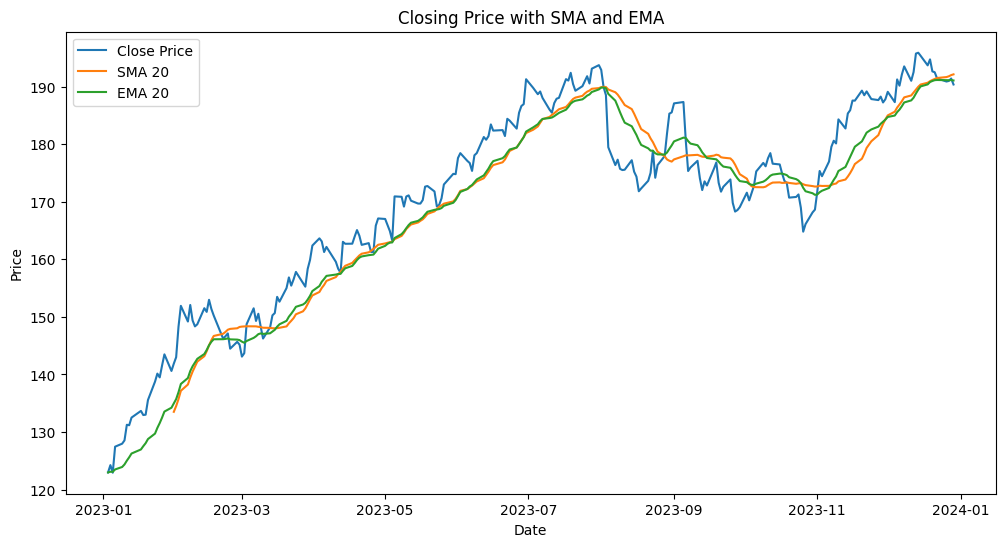

In [3]:
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()

stock_df['EMA_20'] = stock_df['Close'].ewm(span=20, adjust=False).mean()

plt.figure(figsize=(12,6))

plt.plot(stock_df['Close'], label='Close Price')

plt.plot(stock_df['SMA_20'], label='SMA 20')

plt.plot(stock_df['EMA_20'], label='EMA 20')

plt.title('Closing Price with SMA and EMA')

plt.xlabel('Date')

plt.ylabel('Price')

plt.legend()

plt.show()

## Relative Strength Index (RSI)

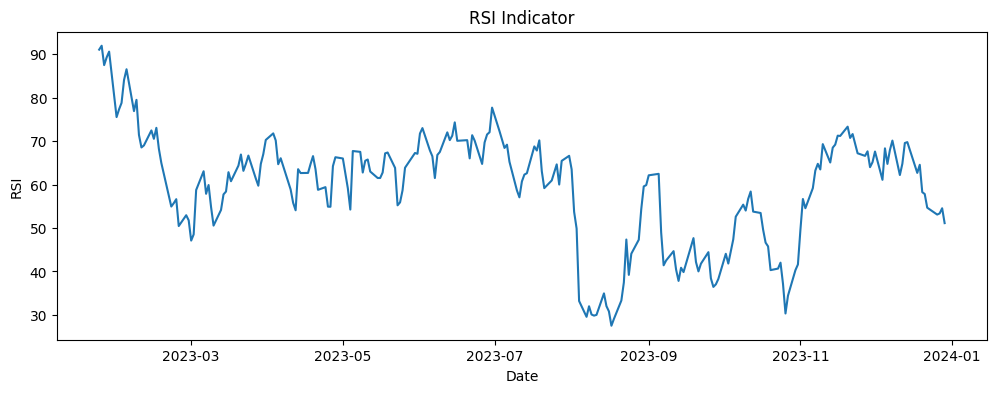

In [5]:
close_prices = stock_df['Close'].squeeze()

stock_df['RSI'] = ta.momentum.RSIIndicator(close=close_prices).rsi()

plt.figure(figsize=(12,4))

plt.plot(stock_df.index, stock_df['RSI'])

plt.title('RSI Indicator')

plt.xlabel('Date')

plt.ylabel('RSI')

plt.show()

## MACD Indicator

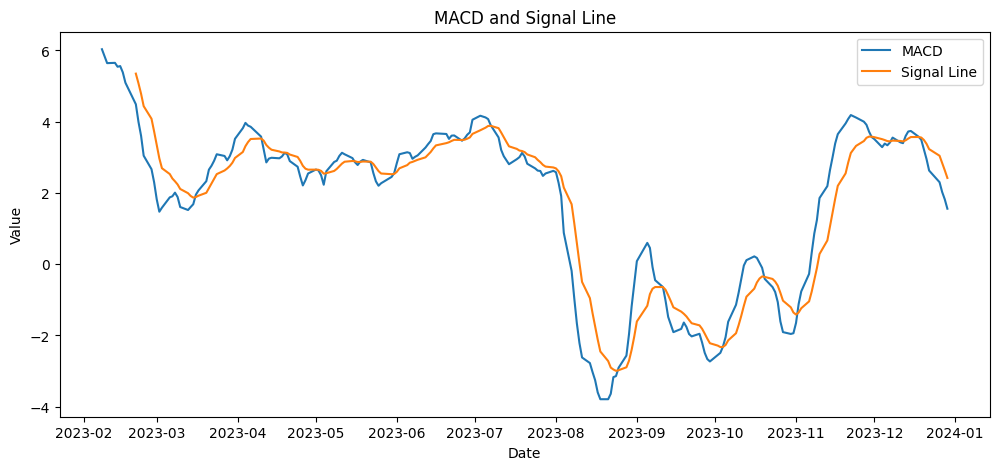

In [7]:
close_prices = stock_df['Close'].squeeze()

macd = ta.trend.MACD(close_prices)

stock_df['MACD'] = macd.macd()

stock_df['MACD_Signal'] = macd.macd_signal()

plt.figure(figsize=(12,5))

plt.plot(stock_df.index, stock_df['MACD'], label='MACD')

plt.plot(stock_df.index, stock_df['MACD_Signal'], label='Signal Line')

plt.title('MACD and Signal Line')

plt.xlabel('Date')

plt.ylabel('Value')

plt.legend()

plt.show()

## PyNance Financial Metrics

In [8]:
daily_return = stock_df['Close'].pct_change()

print(daily_return.describe())

Ticker        AAPL
count   249.000000
mean      0.001835
std       0.012570
min      -0.048020
25%      -0.005891
50%       0.001878
75%       0.008846
max       0.046927


The technical indicators suggest possible trends and momentum changes in stock prices. SMA and EMA smooth price movement, RSI identifies overbought and oversold conditions, while MACD helps identify trend direction and momentum.